In [2]:
import numpy as np
from collections import defaultdict
from sklearn.cluster import KMeans
import re,glob,gzip
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import ks_2samp

#cmap = cm.coolwarm
cdict1 = {'red':   ((0.0, 0.0, 0.0),
                   (0.5, 0.0, 0.1),
                   (1.0, 1.0, 1.0)),

         'green': ((0.0, 0.0, 0.0),
                   (1.0, 0.0, 0.0)),

         'blue':  ((0.0, 0.0, 1.0),
                   (0.5, 0.1, 0.0),
                   (1.0, 0.0, 0.0))
        }
bluered1 = LinearSegmentedColormap('BlueRed1', cdict1)
cmap = bluered1
%matplotlib inline

# MS vs. control

## DMR only

In [212]:
##get label dict
training_sample_label_dict=dict()
testing_sample_label_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/ms_vs_control_table_design_matrix.bin.v2.training.fold0' + str(fold)
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/ms_vs_control_table_design_matrix.bin.v2.testing.fold0' + str(fold)
    training_label_list=[]
    with open(training_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            training_label_list.append(splitline[3])
    training_label_list=np.array(training_label_list,dtype='int32')
    training_sample_label_dict[fold]=training_label_list
    testing_label_list=[]
    with open(testing_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            testing_label_list.append(splitline[3])
    testing_label_list=np.array(testing_label_list,dtype='int32')
    testing_sample_label_dict[fold]=testing_label_list
    



In [213]:
##get sample matrix dict
import math
from sklearn.impute import KNNImputer

training_sample_mat_dict=dict()
testing_sample_mat_dict=dict()


for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/dmrs.ms_vs_control.filtered.training.fold0' + str(fold) + '.add_value.methy.bed.gz'
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/dmrs.ms_vs_control.filtered.testing.fold0' + str(fold) + '.add_value.methy.bed.gz'
    training_mat_list=[]
    with gzip.open(training_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            training_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                training_mat_pos.append(m)
            training_mat_pos = np.array(training_mat_pos,dtype='float32')
            training_mat_list.append(training_mat_pos)
    training_mat_list=np.array(training_mat_list,dtype='float32')
    training_sample_mat_dict[fold]=np.nan_to_num(training_mat_list)
    testing_mat_list=[]
    with gzip.open(testing_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            testing_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                testing_mat_pos.append(m)
            testing_mat_pos = np.array(testing_mat_pos,dtype='float32')
            testing_mat_list.append(testing_mat_pos)
    testing_mat_list=np.array(testing_mat_list,dtype='float32')
    testing_sample_mat_dict[fold]=np.nan_to_num(testing_mat_list)



/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2759625904.py:51: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2759625904.py:51: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2759625904.py:51: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2759625904.py:51: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/275

0.9166666666666667
0.5
0.8
0.9166666666666667
0.8333333333333334
0.6
1.0
1.0
0.6
0.9166666666666667


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2759625904.py:51: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))


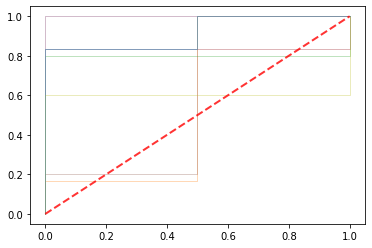

In [216]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm
from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD


random_state=42




tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)


for i in range(10):
    svd = TruncatedSVD(n_components=2, random_state=random_state)

    train_dmr_X = training_sample_mat_dict[i].transpose()
    train_dmr_SVD = svd.fit_transform(train_dmr_X)
    
    train_y = training_sample_label_dict[i]
    
    test_dmr_X = testing_sample_mat_dict[i].transpose()
    test_dmr_SVD = svd.transform(test_dmr_X)
    
    test_y = testing_sample_label_dict[i]
    
    random_state_i = random_state + i
    
   
    classifier = LogisticRegression(penalty='l2', dual=False, tol=1e-5, C=120, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='lbfgs', max_iter=1000, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=None)

    classifier.fit(train_dmr_SVD, train_y)
    final_prob_test = classifier.predict_proba(test_dmr_SVD)[:, 1]

    # Compute ROC curve and area the curve
    fpr, tpr, thresholds = roc_curve(test_y, final_prob_test)
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    print(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
    
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)



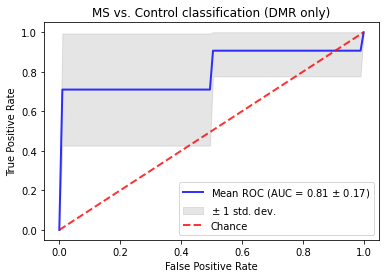

In [218]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MS vs. Control classification (DMR only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/performance_model.ms_vs_control_CV.top2_SVD.logis_l2.pdf", bbox_inches='tight')



## TOO only

In [813]:
##get dictionary of TOO matrix for each sample
too_mat_dict=dict()

with open('/Users/yaping/Documents/workspace/projects/ms_wgbs/too/too_plus_names.uxm_res.75_samples.txt','r') as f:
    for line in f:
        line=line.rstrip('\n')
        splitline = line.split("\t")
        sample_name = splitline[0]
        too_mat_dict[sample_name]=np.array(splitline[2:],dtype='float32')

##get dictionary for subtype
sample_group_dict=dict()

with open('/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control_table_design_matrix.75samples.txt','r') as f:
    for line in f:
        line=line.rstrip('\n')
        splitline = line.split("\t")
        if splitline[1] == 'base':
                continue
        sample_name = splitline[0]
        sample_group_dict[sample_name]=np.array(splitline[5],dtype='int32')


##get label dict and matrix from TOO
training_sample_label_dict=dict()
testing_sample_label_dict=dict()

training_sample_too_mat_dict=dict()
testing_sample_too_mat_dict=dict()

training_sample_group_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/ms_vs_control_table_design_matrix.bin.v2.training.fold0' + str(fold)
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/ms_vs_control_table_design_matrix.bin.v2.testing.fold0' + str(fold)
    training_label_list=[]
    training_group_list=[]
    training_too_mat=[]
    with open(training_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            training_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            training_too_mat.append(too_list)
            group_list=sample_group_dict[sample_name]
            training_group_list.append(group_list)
    training_label_list=np.array(training_label_list,dtype='int32')
    training_sample_label_dict[fold]=training_label_list
    training_too_mat = np.array(training_too_mat,dtype='float32')
    training_sample_too_mat_dict[fold] = training_too_mat
    training_group_list=np.array(training_group_list,dtype='int32')
    training_sample_group_dict[fold]=training_group_list
    
    testing_label_list=[]
    testing_too_mat=[]
    with open(testing_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            testing_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            testing_too_mat.append(too_list)
    testing_label_list=np.array(testing_label_list,dtype='int32')
    testing_sample_label_dict[fold]=testing_label_list
    testing_too_mat = np.array(testing_too_mat,dtype='float32')
    testing_sample_too_mat_dict[fold] = testing_too_mat
    

##get sample matrix dict
import math

training_sample_mat_dict=dict()
testing_sample_mat_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/dmrs.ms_vs_control.filtered.training.fold0' + str(fold) + '.add_value.methy.bed.gz'
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/dmrs.ms_vs_control.filtered.testing.fold0' + str(fold) + '.add_value.methy.bed.gz'
    training_mat_list=[]
    with gzip.open(training_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            training_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                training_mat_pos.append(m)
            training_mat_pos = np.array(training_mat_pos,dtype='float32')
            training_mat_list.append(training_mat_pos)
    training_mat_list=np.array(training_mat_list,dtype='float32')
    training_sample_mat_dict[fold]=np.nan_to_num(training_mat_list)
    testing_mat_list=[]
    with gzip.open(testing_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            testing_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                testing_mat_pos.append(m)
            testing_mat_pos = np.array(testing_mat_pos,dtype='float32')
            testing_mat_list.append(testing_mat_pos)
    testing_mat_list=np.array(testing_mat_list,dtype='float32')
    testing_sample_mat_dict[fold]=np.nan_to_num(testing_mat_list)



In [173]:
def is_significant_one_sided_4groups_allsubsets(feature_values, labels, cutoff=0.05):
    """
    Given feature_values (an array, each entry a sample's value) and labels (in {1,2,3,4}),
    perform the following comparisons using one-sided Mann–Whitney:
      - All non-empty proper subsets S of {1,2,3,4} vs. their complement S^c
        (i.e. S vs. S^c).
        We skip duplicates by ensuring mask < (15 - mask) for 4 groups => skip reversed.
      - If any comparison has p < 0.05, return (True, min_p).
      - Otherwise (False, max_p).

    The direction ("less" or "greater") is chosen by comparing medians:
      if median(S) < median(S^c) => alternative="less"
      else => "greater".

    Parameters
    ----------
    feature_values : 1D array of shape (n_samples,)
        The numeric values for a single feature across all samples
    labels : 1D array of shape (n_samples,) in {1,2,3,4}
        Indicating which group each sample belongs to

    Returns
    -------
    (is_sig, p_min)
      is_sig : bool
          True if any subset vs. complement yields p < 0.05
      p_min : float
          The smallest p-value found across all tested comparisons
    """
    # Split data by group
    group1 = feature_values[labels == 1]
    group2 = feature_values[labels == 2]
    group3 = feature_values[labels == 3]
    group4 = feature_values[labels == 4]

    # Helper to combine an index set (like [1,2]) into the corresponding data
    def combine_data_for_subset(index_set):
        combined = []
        for idx in index_set:
            if idx == 1:
                combined.append(group1)
            elif idx == 2:
                combined.append(group2)
            elif idx == 3:
                combined.append(group3)
            elif idx == 4:
                combined.append(group4)
        if len(combined) == 0:
            return np.array([])
        return np.concatenate(combined)

    # One-sided test function
    def one_sided_mw_test(arrA, arrB):
        if len(arrA) == 0 or len(arrB) == 0:
            return 1.0  # can't do meaningful test
        medA = np.median(arrA)
        medB = np.median(arrB)
        alt = "less" if medA < medB else "greater"
        res = stats.mannwhitneyu(arrA, arrB, alternative=alt)
        #res = stats.mannwhitneyu(arrA, arrB)
        return res.pvalue

    # We'll store p-values
    pvals = []

    # For enumerating subsets of {1,2,3,4}, we use bitmasks from 1..(2^4-1) => 1..15
    # skip empty set (mask=0) or full set (mask=15)
    # also skip reversed duplicates => only do if mask < (15 - mask).
    # i.e. S vs. S^c is same as S^c vs. S reversed
    for mask in range(1, 16):  # 1..15
        if mask == 15:  # full set
            continue
        complement = 15 - mask  # bitwise complement in 4 bits => 1111 - mask
        if mask < complement:
            # define subset S
            S = []
            for bitpos in range(4):  # 0..3
                # check if bit is set
                # if labels are 1..4 => we do bitpos+1
                if (mask & (1 << bitpos)) != 0:
                    S.append(bitpos+1)

            if len(S) == 0 or len(S) == 4:
                continue

            # define S^c
            # For 4 groups, that's simply set {1,2,3,4} minus S
            # but we can do the bit approach or standard python set approach
            # but we already know complement = ...
            # We'll just do a python set difference
            fullset = {1,2,3,4}
            S_c = list(fullset.difference(S))

            arrS   = combine_data_for_subset(S)
            arrSc  = combine_data_for_subset(S_c)

            pval = one_sided_mw_test(arrS, arrSc)
            pvals.append(pval)

    # If you specifically want the 6 pairwise single-group comparisons, e.g. (1 vs 2), (1 vs 3), etc.
    # ignoring other groups, do it here:
    pairwise_groups = [(1,2),(1,3),(1,4),(2,3),(2,4),(3,4)]
    for (gA, gB) in pairwise_groups:
        arrA = combine_data_for_subset([gA])  # just group gA
        arrB = combine_data_for_subset([gB])  # just group gB
        pval = one_sided_mw_test(arrA, arrB)
        pvals.append(pval)

    # Now we have a list of pvals from all subset vs complement and all pairwise single-group
    if len(pvals) == 0:
        return (False, 1.0)  # no comparisons done
    p_min = np.min(pvals)
    is_sig = (p_min < cutoff)
    return (is_sig, p_min)

Number of features selected: (67, 6)
Number of features selected: (67, 5)
Number of features selected: (68, 6)
Number of features selected: (67, 3)
Number of features selected: (68, 5)
Number of features selected: (68, 6)
Number of features selected: (67, 4)
Number of features selected: (67, 5)
Number of features selected: (69, 5)
Number of features selected: (67, 4)


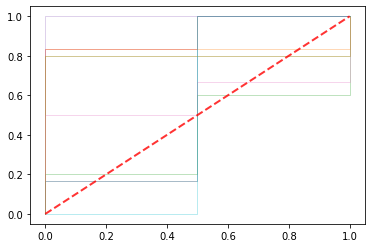

In [814]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
##these are the index for immune and CNS cells
index = [2,3,4,5,6,12,22,23,30]


ms_control_too_mask_dict=dict()
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for i in range(10):
    train_X = training_sample_too_mat_dict[i][:,index]
    train_y = training_sample_label_dict[i]
    
    test_X = testing_sample_too_mat_dict[i][:,index]
    test_y = testing_sample_label_dict[i]

    classifier = GradientBoostingClassifier(n_estimators=200, learning_rate=0.2, max_depth=10, random_state=random_state,min_samples_split=2,min_samples_leaf=1,subsample=0.8,max_features='log2')

    n_features = train_X.shape[1]
    ms_groups_train = training_sample_group_dict[i]

    # Step A: For each feature, do a one-sided Mann–Whitney on the training fold
    pvals = []
    significance_mask = np.zeros(n_features, dtype=bool)
    for col in range(n_features):
        col_values = train_X[:, col]
        sig, pval = is_significant_one_sided_4groups_allsubsets(col_values, ms_groups_train, 0.05)
        pvals.append(pval)
        if sig:
            significance_mask[col] = True

    # Step B: If no feature passed p<0.05, pick the best feature (lowest p)
    if not significance_mask.any():
        # fallback: pick the single best feature
        best_col = np.argmin(pvals)
        significance_mask[best_col] = True

    # select these features
    train_X_sel = train_X[:, significance_mask]
    test_X_sel  = test_X[:, significance_mask]
    ms_control_too_mask_dict[i]=significance_mask
    print("Number of features selected:", train_X[:, significance_mask].shape)

    # Step C: Fit classifier on selected features
    classifier.fit(train_X_sel, train_y)

    # Step D: Predict probabilities, get ROC
    probas_ = classifier.predict_proba(test_X_sel)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    # store tpr after interpolation
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label=f'Fold {i} (AUC={roc_auc:.2f})')
    i += 1
    
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




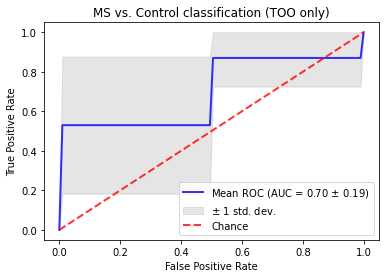

In [815]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MS vs. Control classification (TOO only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
#f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/too/performance_model.diff_too_neuron_immune.ms_vs_control_CV.gbt.pdf", bbox_inches='tight')


# Progressive MS vs. RRMS

## DMR only (Progressive MS vs. RRMS)

In [219]:
##get label dict
training_sample_label_dict=dict()
testing_sample_label_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progressive_vs_rrms/progressive_vs_rrms_table_design_matrix.bin.v2.training.fold0' + str(fold)
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progressive_vs_rrms/progressive_vs_rrms_table_design_matrix.bin.v2.testing.fold0' + str(fold)
    training_label_list=[]
    with open(training_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            training_label_list.append(splitline[3])
    training_label_list=np.array(training_label_list,dtype='int32')
    training_sample_label_dict[fold]=training_label_list
    testing_label_list=[]
    with open(testing_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            testing_label_list.append(splitline[3])
    testing_label_list=np.array(testing_label_list,dtype='int32')
    testing_sample_label_dict[fold]=testing_label_list
    
##get sample matrix dict

training_sample_mat_dict=dict()
testing_sample_mat_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progressive_vs_rrms/dmrs.progressive_vs_rrms.filtered.training.fold0' + str(fold) + '.add_value.methy.bed.gz'
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progressive_vs_rrms/dmrs.progressive_vs_rrms.filtered.testing.fold0' + str(fold) + '.add_value.methy.bed.gz'
    training_mat_list=[]
    with gzip.open(training_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            training_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                training_mat_pos.append(m)
            training_mat_pos = np.array(training_mat_pos,dtype='float32')
            training_mat_list.append(training_mat_pos)
    training_mat_list=np.array(training_mat_list,dtype='float32')
    training_sample_mat_dict[fold]=np.nan_to_num(training_mat_list)
    testing_mat_list=[]
    with gzip.open(testing_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            testing_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                testing_mat_pos.append(m)
            testing_mat_pos = np.array(testing_mat_pos,dtype='float32')
            testing_mat_list.append(testing_mat_pos)
    testing_mat_list=np.array(testing_mat_list,dtype='float32')
    testing_sample_mat_dict[fold]=np.nan_to_num(testing_mat_list)




Number of features selected: 35


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2426465597.py:49: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))


Number of features selected: 22


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2426465597.py:49: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))


Number of features selected: 11


...

/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2426465597.py:49: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))


Number of features selected: 19


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2426465597.py:49: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))


Number of features selected: 14


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2426465597.py:49: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))


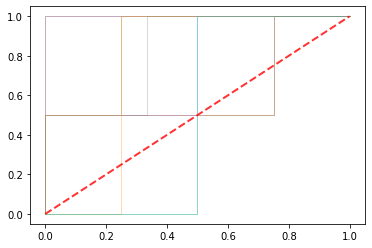

In [258]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)

classifier = LGBMClassifier(n_estimators=100,learning_rate=0.1,num_leaves=31,max_depth=-1,reg_alpha=0.1,reg_lambda=0.1,subsample=0.8, colsample_bytree=0.8,min_child_samples=10)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

selected_dmrs_dict=dict()

for i in range(10):
    train_X = training_sample_mat_dict[i].transpose()
    train_y = training_sample_label_dict[i]
    
    min_features_to_select = 1  # Minimum number of features to consider
    rfecv = RFECV(
        estimator=classifier,
        step=1,
        cv=cv,
        scoring='accuracy',
        min_features_to_select=min_features_to_select,
        n_jobs=-1,
    )
    rfecv.fit(train_X, train_y)
    print("Number of features selected:", rfecv.n_features_)

    test_X = testing_sample_mat_dict[i].transpose()
    test_y = testing_sample_label_dict[i]
    
    probas_ = classifier.fit(train_X[:,rfecv.support_], train_y).predict_proba(test_X[:,rfecv.support_])
    selected_dmrs_dict[i]=rfecv.support_
    # Compute ROC curve and area the curve
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)



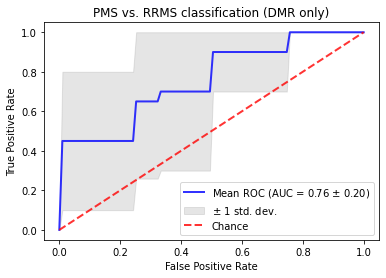

In [259]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('PMS vs. RRMS classification (DMR only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
#f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progressive_vs_rrms/performance_model.progressive_vs_rrms_CV.REFCV.lightGBM.pdf", bbox_inches='tight')


## TOO only (Progressive MS vs. RRMS)

In [260]:
##get label dict and matrix from TOO
training_sample_label_dict=dict()
testing_sample_label_dict=dict()

training_sample_too_mat_dict=dict()
testing_sample_too_mat_dict=dict()

training_sample_group_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progressive_vs_rrms/progressive_vs_rrms_table_design_matrix.bin.v2.training.fold0' + str(fold)
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progressive_vs_rrms/progressive_vs_rrms_table_design_matrix.bin.v2.testing.fold0' + str(fold)
    training_label_list=[]
    training_group_list=[]
    training_too_mat=[]
    with open(training_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            training_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            training_too_mat.append(too_list)
            group_list=sample_group_dict[sample_name]
            training_group_list.append(group_list)
    training_label_list=np.array(training_label_list,dtype='int32')
    training_sample_label_dict[fold]=training_label_list
    training_too_mat = np.array(training_too_mat,dtype='float32')
    training_sample_too_mat_dict[fold] = training_too_mat
    training_group_list=np.array(training_group_list,dtype='int32')
    training_sample_group_dict[fold]=training_group_list
    
    testing_label_list=[]
    testing_too_mat=[]
    with open(testing_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            testing_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            testing_too_mat.append(too_list)
    testing_label_list=np.array(testing_label_list,dtype='int32')
    testing_sample_label_dict[fold]=testing_label_list
    testing_too_mat = np.array(testing_too_mat,dtype='float32')
    testing_sample_too_mat_dict[fold] = testing_too_mat
    



##get sample matrix dict

training_sample_mat_dict=dict()
testing_sample_mat_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progressive_vs_rrms/dmrs.progressive_vs_rrms.filtered.training.fold0' + str(fold) + '.add_value.methy.bed.gz'
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progressive_vs_rrms/dmrs.progressive_vs_rrms.filtered.testing.fold0' + str(fold) + '.add_value.methy.bed.gz'
    training_mat_list=[]
    with gzip.open(training_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            training_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                training_mat_pos.append(m)
            training_mat_pos = np.array(training_mat_pos,dtype='float32')
            training_mat_list.append(training_mat_pos)
    training_mat_list=np.array(training_mat_list,dtype='float32')
    training_sample_mat_dict[fold]=np.nan_to_num(training_mat_list)
    testing_mat_list=[]
    with gzip.open(testing_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            testing_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                testing_mat_pos.append(m)
            testing_mat_pos = np.array(testing_mat_pos,dtype='float32')
            testing_mat_list.append(testing_mat_pos)
    testing_mat_list=np.array(testing_mat_list,dtype='float32')
    testing_sample_mat_dict[fold]=np.nan_to_num(testing_mat_list)



Number of features selected: (51, 4)
Number of features selected: (51, 7)
Number of features selected: (51, 5)
Number of features selected: (51, 4)
Number of features selected: (52, 5)
Number of features selected: (51, 4)
Number of features selected: (51, 6)
Number of features selected: (52, 6)
Number of features selected: (51, 5)
Number of features selected: (52, 6)


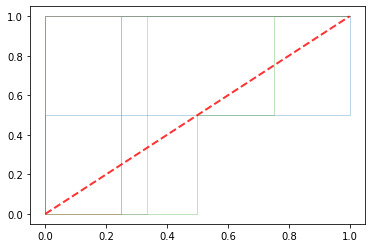

In [353]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
index = [2,3,4,5,6,12,22,23,30]


tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for i in range(10):
    train_X = training_sample_too_mat_dict[i][:,index]
    train_y = training_sample_label_dict[i]
    
    test_X = testing_sample_too_mat_dict[i][:,index]
    test_y = testing_sample_label_dict[i]

    classifier = svm.SVC(C=8, kernel='rbf', probability=True, random_state=random_state)

    n_features = train_X.shape[1]
    ms_groups_train = training_sample_group_dict[i]

    # Step A: For each feature, do a one-sided Mann–Whitney on the training fold
    pvals = []
    significance_mask = np.zeros(n_features, dtype=bool)
    for col in range(n_features):
        col_values = train_X[:, col]
        sig, pval = is_significant_one_sided_4groups_allsubsets(col_values, ms_groups_train, 0.1)
        pvals.append(pval)
        if sig:
            significance_mask[col] = True

    # Step B: If no feature passed p<0.05, pick the best feature (lowest p)
    if not significance_mask.any():
        # fallback: pick the single best feature
        best_col = np.argmin(pvals)
        significance_mask[best_col] = True

    # select these features
    train_X_sel = train_X[:, significance_mask]
    test_X_sel  = test_X[:, significance_mask]
    
    print("Number of features selected:", train_X[:, significance_mask].shape)
    # Step C: Fit classifier on selected features
    classifier.fit(train_X_sel, train_y)

    # Step D: Predict probabilities, get ROC
    probas_ = classifier.predict_proba(test_X_sel)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    # store tpr after interpolation
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label=f'Fold {i} (AUC={roc_auc:.2f})')
    i += 1
    
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




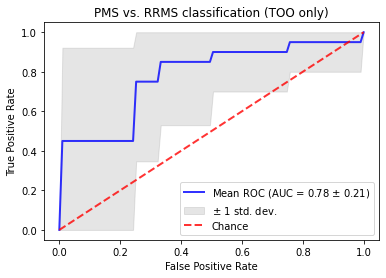

In [355]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('PMS vs. RRMS classification (TOO only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/too/performance_model.too_diff_neuron_immune.pms_vs_rrms_CV.svm_rbf.pdf", bbox_inches='tight')


# Active relapse RRMS vs. Stable remission RRMS

## DMR only (Active relapse RRMS vs. Stable remission RRMS)

In [428]:
##get label dict and matrix from TOO
training_sample_label_dict=dict()
testing_sample_label_dict=dict()

training_sample_too_mat_dict=dict()
testing_sample_too_mat_dict=dict()

training_sample_group_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/active_vs_stable/active_vs_stable_table_design_matrix.bin.v2.training.fold0' + str(fold)
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/active_vs_stable/active_vs_stable_table_design_matrix.bin.v2.testing.fold0' + str(fold)
    training_label_list=[]
    training_group_list=[]
    training_too_mat=[]
    with open(training_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            training_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            training_too_mat.append(too_list)
            group_list=sample_group_dict[sample_name]
            training_group_list.append(group_list)
    training_label_list=np.array(training_label_list,dtype='int32')
    training_sample_label_dict[fold]=training_label_list
    training_too_mat = np.array(training_too_mat,dtype='float32')
    training_sample_too_mat_dict[fold] = training_too_mat
    training_group_list=np.array(training_group_list,dtype='int32')
    training_sample_group_dict[fold]=training_group_list
    
    testing_label_list=[]
    testing_too_mat=[]
    with open(testing_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            testing_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            testing_too_mat.append(too_list)
    testing_label_list=np.array(testing_label_list,dtype='int32')
    testing_sample_label_dict[fold]=testing_label_list
    testing_too_mat = np.array(testing_too_mat,dtype='float32')
    testing_sample_too_mat_dict[fold] = testing_too_mat
    



##get sample matrix dict

training_sample_mat_dict=dict()
testing_sample_mat_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/active_vs_stable/dmrs.active_vs_stable.filtered.training.fold0' + str(fold) + '.add_value.methy.bed.gz'
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/active_vs_stable/dmrs.active_vs_stable.filtered.testing.fold0' + str(fold) + '.add_value.methy.bed.gz'
    training_mat_list=[]
    with gzip.open(training_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            training_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                training_mat_pos.append(m)
            training_mat_pos = np.array(training_mat_pos,dtype='float32')
            training_mat_list.append(training_mat_pos)
    training_mat_list=np.array(training_mat_list,dtype='float32')
    training_sample_mat_dict[fold]=np.nan_to_num(training_mat_list)
    testing_mat_list=[]
    with gzip.open(testing_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            testing_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                testing_mat_pos.append(m)
            testing_mat_pos = np.array(testing_mat_pos,dtype='float32')
            testing_mat_list.append(testing_mat_pos)
    testing_mat_list=np.array(testing_mat_list,dtype='float32')
    testing_sample_mat_dict[fold]=np.nan_to_num(testing_mat_list)



0.5
0.33333333333333337
0.6666666666666667
0.5
0.33333333333333337
1.0
1.0
0.33333333333333337
1.0
1.0


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2161042704.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2161042704.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2161042704.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2161042704.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/216

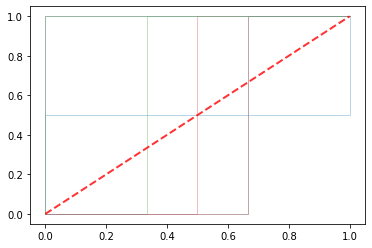

In [519]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm
from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD


random_state=42


tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)


for i in range(10):
    svd = TruncatedSVD(n_components=3, random_state=random_state)

    train_dmr_X = training_sample_mat_dict[i].transpose()
    train_dmr_SVD = svd.fit_transform(train_dmr_X)
    
    train_y = training_sample_label_dict[i]
    
    test_dmr_X = testing_sample_mat_dict[i].transpose()
    test_dmr_SVD = svd.transform(test_dmr_X)
    
    test_y = testing_sample_label_dict[i]
    
    random_state_i = random_state + i
    
    classifier = svm.SVC(kernel='rbf', probability=True,gamma='scale',C=0.1,random_state=random_state)

    classifier.fit(train_dmr_SVD, train_y)

    final_prob_test = classifier.predict_proba(test_dmr_SVD)[:, 1]

    # Compute ROC curve and area the curve
    fpr, tpr, thresholds = roc_curve(test_y, final_prob_test)
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    print(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
    
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)



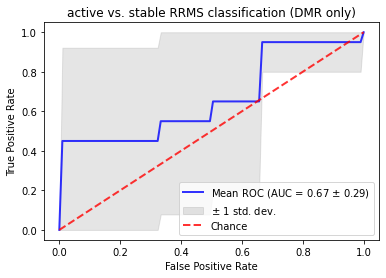

In [520]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('active vs. stable RRMS classification (DMR only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/active_vs_stable/performance_model.active_vs_stable_CV.SVD3.SVM_rbf_C0.1.pdf", bbox_inches='tight')


## TOO only (Active relapse RRMS vs. Stable remission RRMS)

Number of features selected: (34, 5)
Number of features selected: (35, 5)
Number of features selected: (35, 4)
Number of features selected: (36, 5)
Number of features selected: (35, 6)
Number of features selected: (35, 5)
Number of features selected: (35, 5)
Number of features selected: (35, 5)
Number of features selected: (35, 5)
Number of features selected: (36, 5)


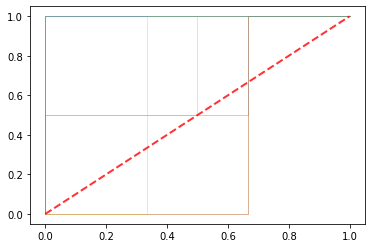

In [642]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
index = [2,3,4,5,6,12,22,23,30]


tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for i in range(10):
    train_X = training_sample_too_mat_dict[i][:,index]
    train_y = training_sample_label_dict[i]
    
    test_X = testing_sample_too_mat_dict[i][:,index]
    test_y = testing_sample_label_dict[i]

    classifier = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=100, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=None)
 
    n_features = train_X.shape[1]
    ms_groups_train = training_sample_group_dict[i]

    # Step A: For each feature, do a one-sided Mann–Whitney on the training fold
    pvals = []
    significance_mask = np.zeros(n_features, dtype=bool)
    for col in range(n_features):
        col_values = train_X[:, col]
        sig, pval = is_significant_one_sided_4groups_allsubsets(col_values, ms_groups_train, 0.2)
        pvals.append(pval)
        if sig:
            significance_mask[col] = True

    # Step B: If no feature passed p<0.05, pick the best feature (lowest p)
    if not significance_mask.any():
        # fallback: pick the single best feature
        best_col = np.argmin(pvals)
        significance_mask[best_col] = True

    # select these features
    train_X_sel = train_X[:, significance_mask]
    test_X_sel  = test_X[:, significance_mask]
    
    print("Number of features selected:", train_X[:, significance_mask].shape)
    # Step C: Fit classifier on selected features
    classifier.fit(train_X_sel, train_y)

    # Step D: Predict probabilities, get ROC
    probas_ = classifier.predict_proba(test_X_sel)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    # store tpr after interpolation
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label=f'Fold {i} (AUC={roc_auc:.2f})')
    i += 1
    
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




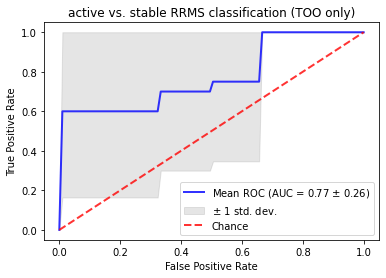

In [643]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('active vs. stable RRMS classification (TOO only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/too/performance_model.too_diff_neuron_immune.active_vs_stable_CV.l2C100.pdf", bbox_inches='tight')





# Severe vs. Mild

## DMR only (Severe vs. Mild)

In [902]:
##get label dict and matrix from TOO
training_sample_label_dict=dict()
testing_sample_label_dict=dict()

training_sample_too_mat_dict=dict()
testing_sample_too_mat_dict=dict()

training_sample_group_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/pdds_severe_vs_mild_v3/pdds_severe_vs_mild_table_design_matrix.pdds_collect_in_10days.bin.training.fold0' + str(fold)
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/pdds_severe_vs_mild_v3/pdds_severe_vs_mild_table_design_matrix.pdds_collect_in_10days.bin.testing.fold0' + str(fold)
    training_label_list=[]
    training_group_list=[]
    training_too_mat=[]
    with open(training_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            training_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            training_too_mat.append(too_list)
            group_list=sample_group_dict[sample_name]
            training_group_list.append(group_list)
    training_label_list=np.array(training_label_list,dtype='int32')
    training_sample_label_dict[fold]=training_label_list
    training_too_mat = np.array(training_too_mat,dtype='float32')
    training_sample_too_mat_dict[fold] = training_too_mat
    training_group_list=np.array(training_group_list,dtype='int32')
    training_sample_group_dict[fold]=training_group_list
    
    testing_label_list=[]
    testing_too_mat=[]
    with open(testing_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            testing_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            testing_too_mat.append(too_list)
    testing_label_list=np.array(testing_label_list,dtype='int32')
    testing_sample_label_dict[fold]=testing_label_list
    testing_too_mat = np.array(testing_too_mat,dtype='float32')
    testing_sample_too_mat_dict[fold] = testing_too_mat
    



##get sample matrix dict

training_sample_mat_dict=dict()
testing_sample_mat_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/pdds_severe_vs_mild_v3/dmrs.pdds_severe_vs_mild.filtered.training.fold0' + str(fold) + '.add_value.methy.bed.gz'
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/pdds_severe_vs_mild_v3/dmrs.pdds_severe_vs_mild.filtered.testing.fold0' + str(fold) + '.add_value.methy.bed.gz'
    training_mat_list=[]
    with gzip.open(training_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            training_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                training_mat_pos.append(m)
            training_mat_pos = np.array(training_mat_pos,dtype='float32')
            training_mat_list.append(training_mat_pos)
    training_mat_list=np.array(training_mat_list,dtype='float32')
    training_sample_mat_dict[fold]=np.nan_to_num(training_mat_list)
    testing_mat_list=[]
    with gzip.open(testing_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            testing_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                testing_mat_pos.append(m)
            testing_mat_pos = np.array(testing_mat_pos,dtype='float32')
            testing_mat_list.append(testing_mat_pos)
    testing_mat_list=np.array(testing_mat_list,dtype='float32')
    testing_sample_mat_dict[fold]=np.nan_to_num(testing_mat_list)



/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yapin

0.75
1.0


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


1.0


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


...

/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


1.0


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


0.5
1.0
1.0


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))


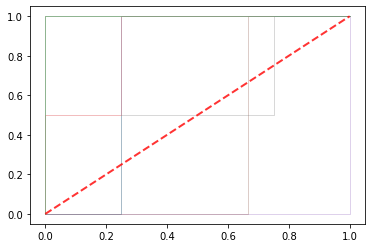

In [774]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm
from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD


random_state=42




tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)


for i in range(10):

    train_dmr_X = training_sample_mat_dict[i].transpose()   
    train_y = training_sample_label_dict[i]
    
    test_dmr_X = testing_sample_mat_dict[i].transpose()   
    test_y = testing_sample_label_dict[i]
    
    random_state_i = random_state + i
    
    classifier = xgboost.XGBClassifier(max_depth=3, learning_rate=0.4, n_estimators=1000, class_weight='balanced', objective='binary:logistic',subsample=0.667,n_jobs=4)

    classifier.fit(train_dmr_X, train_y)

    final_prob_test = classifier.predict_proba(test_dmr_X)[:, 1]

    # Compute ROC curve and area the curve
    fpr, tpr, thresholds = roc_curve(test_y, final_prob_test)
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    print(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
    
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)



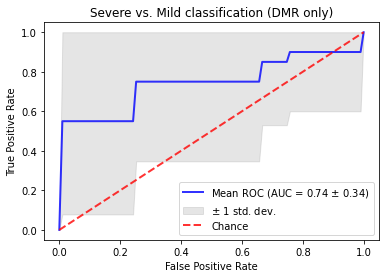

In [775]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Severe vs. Mild classification (DMR only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/pdds_severe_vs_mild_v3/performance_model.pdds_severe_vs_mild_v3_CV.xgboost.pdf", bbox_inches='tight')


## TOO only (Severe vs. Mild)

(40, 8)
0.375
(42, 6)
1.0
(42, 6)
1.0
(40, 6)
0.5
(42, 5)
1.0
(42, 6)
0.6666666666666667
(42, 7)
1.0
(40, 4)
1.0
(42, 5)
1.0
(42, 5)
0.6666666666666667


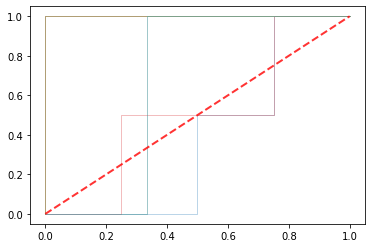

In [1000]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
##these are the index for all the immune cells and epithelial cells
index = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,18,20,21,24,30,31,33,35]

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for i in range(10):
    train_X = training_sample_too_mat_dict[i][:,index]
    train_y = training_sample_label_dict[i]
    
    test_X = testing_sample_too_mat_dict[i][:,index]
    test_y = testing_sample_label_dict[i]

    classifier = GradientBoostingClassifier(n_estimators=200, learning_rate=0.15, max_depth=2, random_state=random_state,min_samples_split=2,min_samples_leaf=2,subsample=0.8,max_features='log2')
    
    n_features = train_X.shape[1]
    # Step A: For each feature, do a one-sided Mann–Whitney on the training fold
    pvals = []
    significance_mask = np.zeros(n_features, dtype=bool)
    for col in range(n_features):
        col_values = train_X[:, col]
        sig, pval = is_significant_one_sided(col_values, train_y, 0.1)
        pvals.append(pval)
        if sig:
            significance_mask[col] = True

    # Step B: If no feature passed p<0.05, pick the best feature (lowest p)
    if not significance_mask.any():
        # fallback: pick the single best feature
        best_col = np.argmin(pvals)
        significance_mask[best_col] = True

    #significance_mask=ms_control_too_mask_dict[i]
    train_X_sel = train_X[:, significance_mask]
    test_X_sel  = test_X[:, significance_mask]
    
    print(train_X_sel.shape)
    classifier.fit(train_X_sel, train_y)

    # Step D: Predict probabilities, get ROC
    probas_ = classifier.predict_proba(test_X_sel)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    # store tpr after interpolation
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    print(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label=f'Fold {i} (AUC={roc_auc:.2f})')
    i += 1
    
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




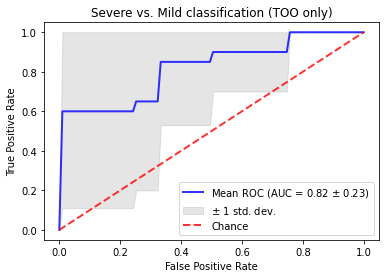

In [1001]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Severe vs. Mild classification (TOO only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/too/performance_model.too_diff_neuron_immune_in_ms_control.pdds_severe_vs_mild_v3_CV.gbt.pdf", bbox_inches='tight')





# Prognostic prediction

## Time 0 (Prognostic prediction)

In [1003]:
####read data matrix 
severe_vs_mild_time0_matrix=[]
severe_vs_mild_time0_too_matrix=[]
severe_vs_mild_time0_labels=[]


with gzip.open('/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progression/corrected_covar.location_fdr001_model.base_time0.add_methy.bed.gz','rt') as f:
    for line in f:
        line=line.rstrip('\n')
        splitline = line.split("\t")
        mat_pos=[]
        for i in range(6,len(splitline),2):
            j=i+1
            if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                m = np.nan
            else:
                m = float(splitline[i])/float(splitline[j])
            mat_pos.append(m)
        mat_pos = np.array(mat_pos,dtype='float32')
        severe_vs_mild_time0_matrix.append(mat_pos)
severe_vs_mild_time0_matrix = np.array(severe_vs_mild_time0_matrix,dtype='float32')
severe_vs_mild_time0_matrix = np.nan_to_num(severe_vs_mild_time0_matrix)
severe_vs_mild_time0_matrix = np.transpose(severe_vs_mild_time0_matrix)

with open('/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progression/pdds.data.inter.base_time0.txt','r') as f:
    for line in f:
        line=line.rstrip('\n')
        splitline = line.split("\t")
        severe_vs_mild_time0_labels.append(int(splitline[3]))
        sample_name = splitline[0]
        too_list = too_mat_dict[sample_name]
        severe_vs_mild_time0_too_matrix.append(too_list)

severe_vs_mild_time0_too_matrix = np.array(severe_vs_mild_time0_too_matrix,dtype='float32')
severe_vs_mild_time0_labels = np.array(severe_vs_mild_time0_labels,dtype='int32')


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2518185514.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2518185514.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2518185514.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2518185514.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/251

/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2518185514.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2518185514.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2518185514.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2518185514.py:58: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/251

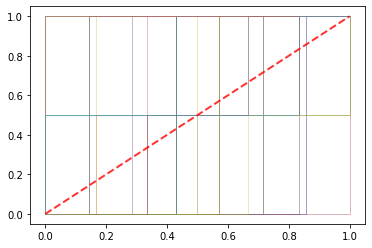

In [1049]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = RepeatedStratifiedKFold(n_splits=5,n_repeats=10, random_state=random_state)
X = severe_vs_mild_time0_matrix
y = severe_vs_mild_time0_labels

svd = TruncatedSVD(n_components=10, random_state=random_state)

classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=random_state,min_samples_split=2,min_samples_leaf=1,subsample=0.8,max_features='log2')

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for train, test in cv.split(X, y):
    train_X = X[train]
    train_y = y[train]
    test_X = X[test]
    test_y = y[test]
    train_X_svd=svd.fit_transform(train_X)
    test_X_svd=svd.transform(test_X)

    # Compute ROC curve and area the curve
    probas_ = classifier.fit(train_X_svd, train_y).predict_proba(test_X_svd)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




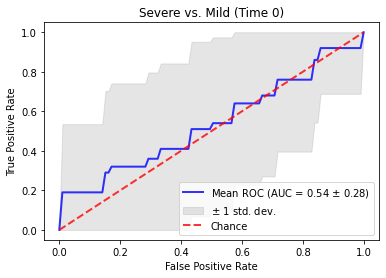

In [1050]:

f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Severe vs. Mild (Time 0)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()

f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/performance_model.progression_time0.corrected_covar.pdds_severe_vs_mild_CV.gbt.pdf", bbox_inches='tight')




## Time 1500 (Prognostic)

/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/1845393388.py:77: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/1845393388.py:77: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/1845393388.py:77: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/1845393388.py:77: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/184

/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/1845393388.py:77: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/1845393388.py:77: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/1845393388.py:77: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/1845393388.py:77: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/184

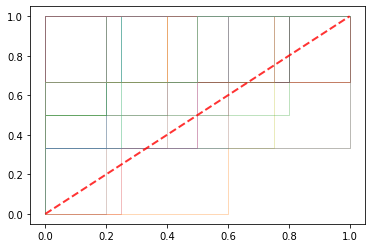

In [1039]:
#Time 1500
####read data matrix 
severe_vs_mild_time1500_matrix=[]
severe_vs_mild_time1500_labels=[]


with gzip.open('/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progression/corrected_covar.location_fdr001_model.tim1500.add_methy.bed.gz','rt') as f:
    for line in f:
        line=line.rstrip('\n')
        splitline = line.split("\t")
        mat_pos=[]
        for i in range(6,len(splitline),2):
            j=i+1
            if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                m = np.nan
            else:
                m = float(splitline[i])/float(splitline[j])
            mat_pos.append(m)
        mat_pos = np.array(mat_pos,dtype='float32')
        severe_vs_mild_time1500_matrix.append(mat_pos)
severe_vs_mild_time1500_matrix = np.array(severe_vs_mild_time1500_matrix,dtype='float32')
severe_vs_mild_time1500_matrix = np.nan_to_num(severe_vs_mild_time1500_matrix)
severe_vs_mild_time1500_matrix = np.transpose(severe_vs_mild_time1500_matrix)

with open('/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/progression/pdds.data.inter.tim1500.txt','r') as f:
    for line in f:
        line=line.rstrip('\n')
        splitline = line.split("\t")
        severe_vs_mild_time1500_labels.append(int(splitline[3]))

severe_vs_mild_time1500_labels = np.array(severe_vs_mild_time1500_labels,dtype='int32')


random_state=42
cv = RepeatedStratifiedKFold(n_splits=5,n_repeats=10, random_state=random_state)
X = severe_vs_mild_time1500_matrix
y = severe_vs_mild_time1500_labels

svd = TruncatedSVD(n_components=10, random_state=random_state)

classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=random_state,min_samples_split=2,min_samples_leaf=1,subsample=0.8,max_features='log2')

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for train, test in cv.split(X, y):
    train_X = X[train]
    train_y = y[train]
    test_X = X[test]
    test_y = y[test]
    train_X_svd=svd.fit_transform(train_X)
    test_X_svd=svd.transform(test_X)

    # Compute ROC curve and area the curve
    probas_ = classifier.fit(train_X_svd, train_y).predict_proba(test_X_svd)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)


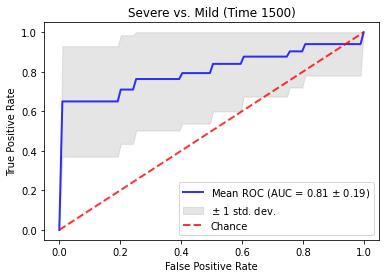

In [1040]:

f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Severe vs. Mild (Time 1500)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()

f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/performance_model.progression_time1500.corrected_covar.pdds_severe_vs_mild_CV.gbt.pdf", bbox_inches='tight')




# Predictive performance by protein biomarkers in the same cohort (NfL and GFAP)

## predict subtypes

In [4]:
####read data matrix (look at study B first)
ms_vs_control_nfl_matrix=[]
ms_vs_control_gfap_matrix=[]
ms_vs_control_labels=[]

pms_vs_rrms_nfl_matrix=[]
pms_vs_rrms_gfap_matrix=[]
pms_vs_rrms_labels=[]

active_vs_stable_nfl_matrix=[]
active_vs_stable_gfap_matrix=[]
active_vs_stable_labels=[]

pdds_label_list=[] ##only use samples with pdds<=1 and pdds>=6
pdds_nfl_matrix=[]
pdds_gfap_matrix=[]

with open('/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/proteins/20250111_NFL_GFAP_Data.txt','r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'id':
                continue
            if splitline[2] != 'B':##only use study B first
                continue
            if splitline[14] == 'Control':
                ms_vs_control_labels.append(0)
                ms_vs_control_nfl_matrix.append(splitline[12])
                ms_vs_control_gfap_matrix.append(splitline[11])
            elif splitline[14] == 'PPMS' or splitline[14] == 'SPMS':
                ms_vs_control_labels.append(1)
                ms_vs_control_nfl_matrix.append(splitline[12])
                ms_vs_control_gfap_matrix.append(splitline[11])
                pms_vs_rrms_labels.append(1)
                pms_vs_rrms_nfl_matrix.append(splitline[12])
                pms_vs_rrms_gfap_matrix.append(splitline[11])
                if splitline[10] != 'NA':
                    pdds=float(splitline[10])
                    if pdds<=1:
                        pdds_label_list.append(0)
                        pdds_nfl_matrix.append(splitline[12])
                        pdds_gfap_matrix.append(splitline[11])
                    elif pdds>=6:
                        pdds_label_list.append(1)
                        pdds_nfl_matrix.append(splitline[12])
                        pdds_gfap_matrix.append(splitline[11])
            elif splitline[14] == 'RRMS':
                ms_vs_control_labels.append(1)
                ms_vs_control_nfl_matrix.append(splitline[12])
                ms_vs_control_gfap_matrix.append(splitline[11])
                pms_vs_rrms_labels.append(0)
                pms_vs_rrms_nfl_matrix.append(splitline[12])
                pms_vs_rrms_gfap_matrix.append(splitline[11])
                if splitline[15] == 'Yes':
                    active_vs_stable_labels.append(1)
                    active_vs_stable_nfl_matrix.append(splitline[12])
                    active_vs_stable_gfap_matrix.append(splitline[11])
                elif splitline[15] == 'No':
                    active_vs_stable_labels.append(0)
                    active_vs_stable_nfl_matrix.append(splitline[12])
                    active_vs_stable_gfap_matrix.append(splitline[11])              
                if splitline[10] != 'NA':
                    pdds=float(splitline[10])
                    if pdds<=1:
                        pdds_label_list.append(0)
                        pdds_nfl_matrix.append(splitline[12])
                        pdds_gfap_matrix.append(splitline[11])
                    elif pdds>=6:
                        pdds_label_list.append(1)
                        pdds_nfl_matrix.append(splitline[12])
                        pdds_gfap_matrix.append(splitline[11])

ms_vs_control_labels = np.array(ms_vs_control_labels,dtype='int32')
pms_vs_rrms_labels = np.array(pms_vs_rrms_labels,dtype='int32')
active_vs_stable_labels = np.array(active_vs_stable_labels,dtype='int32')
pdds_label_list = np.array(pdds_label_list,dtype='int32')

ms_vs_control_nfl_matrix = np.array(ms_vs_control_nfl_matrix,dtype='float32')
ms_vs_control_gfap_matrix = np.array(ms_vs_control_gfap_matrix,dtype='float32')
ms_vs_control_protein_matrix = np.column_stack((ms_vs_control_nfl_matrix,ms_vs_control_gfap_matrix))

pms_vs_rrms_nfl_matrix = np.array(pms_vs_rrms_nfl_matrix,dtype='float32')
pms_vs_rrms_gfap_matrix = np.array(pms_vs_rrms_gfap_matrix,dtype='float32')
pms_vs_rrms_protein_matrix = np.column_stack((pms_vs_rrms_nfl_matrix,pms_vs_rrms_gfap_matrix))

active_vs_stable_nfl_matrix = np.array(active_vs_stable_nfl_matrix,dtype='float32')
active_vs_stable_gfap_matrix = np.array(active_vs_stable_gfap_matrix,dtype='float32')
active_vs_stable_protein_matrix = np.column_stack((active_vs_stable_nfl_matrix,active_vs_stable_gfap_matrix))

pdds_nfl_matrix = np.array(pdds_nfl_matrix,dtype='float32')
pdds_gfap_matrix = np.array(pdds_gfap_matrix,dtype='float32')
pdds_protein_matrix = np.column_stack((pdds_nfl_matrix,pdds_gfap_matrix))


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/3632490213.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/3632490213.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/3632490213.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/3632490213.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/363

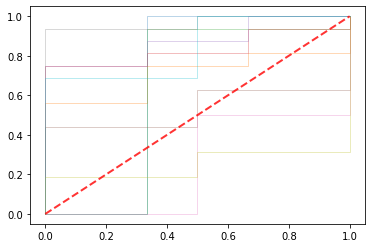

In [5]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
X = ms_vs_control_nfl_matrix.reshape(-1, 1)
y = ms_vs_control_labels

classifier = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=None)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for train, test in cv.split(X, y):
    train_X = X[train]
    train_y = y[train]
    test_X = X[test]
    test_y = y[test]
    
    # Compute ROC curve and area the curve
    probas_ = classifier.fit(train_X, train_y).predict_proba(test_X)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




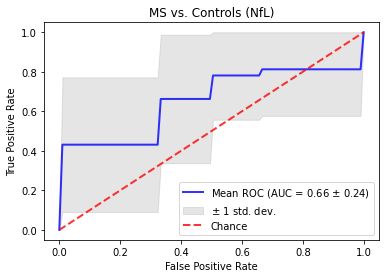

In [6]:

f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MS vs. Controls (NfL)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()

#f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/performance_model.protein_nfl.ms_vs_control_CV.l2.pdf", bbox_inches='tight')




/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2187935216.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2187935216.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2187935216.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2187935216.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/218

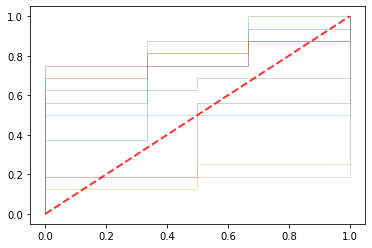

In [7]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
X = ms_vs_control_gfap_matrix.reshape(-1, 1)
y = ms_vs_control_labels

classifier = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=None)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for train, test in cv.split(X, y):
    train_X = X[train]
    train_y = y[train]
    test_X = X[test]
    test_y = y[test]
    
    # Compute ROC curve and area the curve
    probas_ = classifier.fit(train_X, train_y).predict_proba(test_X)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




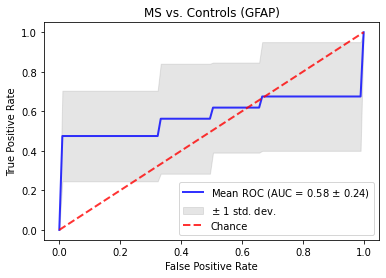

In [8]:

f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MS vs. Controls (GFAP)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()

#f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/performance_model.protein_gfap.ms_vs_control_CV.l2.pdf", bbox_inches='tight')




/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/699334033.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/699334033.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/699334033.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/699334033.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/6993340

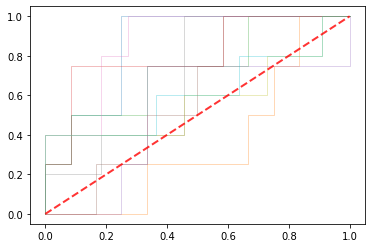

In [9]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
X = pms_vs_rrms_nfl_matrix.reshape(-1, 1)
y = pms_vs_rrms_labels

classifier = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=None)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for train, test in cv.split(X, y):
    train_X = X[train]
    train_y = y[train]
    test_X = X[test]
    test_y = y[test]
    
    # Compute ROC curve and area the curve
    probas_ = classifier.fit(train_X, train_y).predict_proba(test_X)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




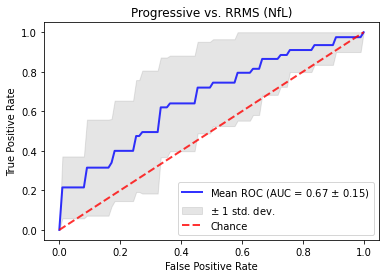

In [10]:

f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Progressive vs. RRMS (NfL)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()

#f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/performance_model.protein_nfl.pms_vs_rrms_CV.l2.pdf", bbox_inches='tight')




/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2450373141.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2450373141.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2450373141.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2450373141.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/245

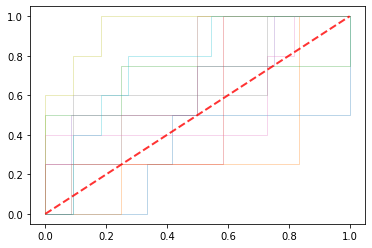

In [11]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
X = pms_vs_rrms_gfap_matrix.reshape(-1, 1)
y = pms_vs_rrms_labels

classifier = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=None)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for train, test in cv.split(X, y):
    train_X = X[train]
    train_y = y[train]
    test_X = X[test]
    test_y = y[test]
    
    # Compute ROC curve and area the curve
    probas_ = classifier.fit(train_X, train_y).predict_proba(test_X)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




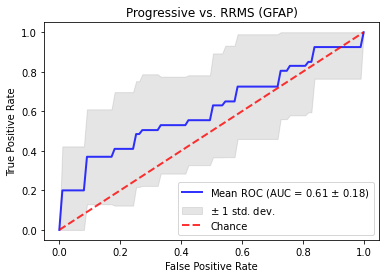

In [12]:

f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Progressive vs. RRMS (GFAP)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()

#f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/performance_model.protein_gfap.pms_vs_rrms_CV.l2.pdf", bbox_inches='tight')




/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/1258376423.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/1258376423.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/1258376423.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/1258376423.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/125

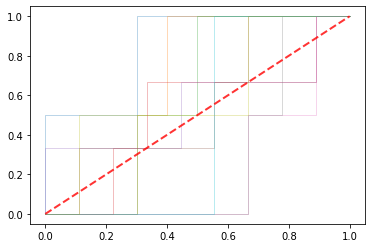

In [13]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
X = active_vs_stable_nfl_matrix.reshape(-1, 1)
y = active_vs_stable_labels

classifier = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=None)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for train, test in cv.split(X, y):
    train_X = X[train]
    train_y = y[train]
    test_X = X[test]
    test_y = y[test]

    # Compute ROC curve and area the curve
    probas_ = classifier.fit(train_X, train_y).predict_proba(test_X)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




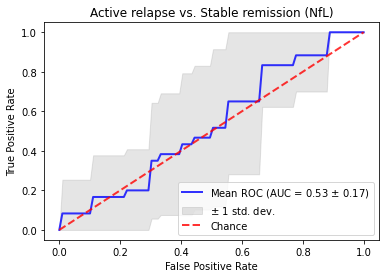

In [14]:

f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Active relapse vs. Stable remission (NfL)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()

#f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/performance_model.protein_nfl.active_vs_stable_CV.l2.pdf", bbox_inches='tight')




/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2782268688.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2782268688.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2782268688.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2782268688.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/278

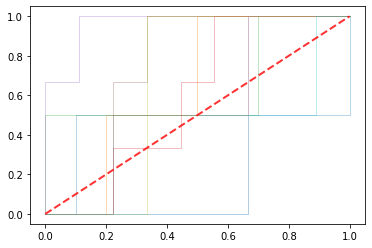

In [15]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
X = active_vs_stable_gfap_matrix.reshape(-1, 1)
y = active_vs_stable_labels

classifier = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=None)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for train, test in cv.split(X, y):
    train_X = X[train]
    train_y = y[train]
    test_X = X[test]
    test_y = y[test]

    # Compute ROC curve and area the curve
    probas_ = classifier.fit(train_X, train_y).predict_proba(test_X)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




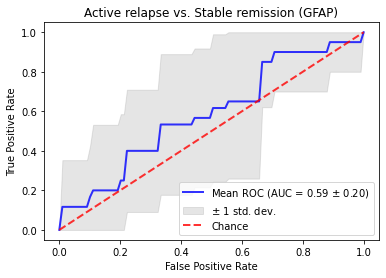

In [16]:

f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Active relapse vs. Stable remission (GFAP)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()

#f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/performance_model.protein_gfap.active_vs_stable_CV.l2.pdf", bbox_inches='tight')




## predict disability severity

/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/286633469.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/286633469.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/286633469.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/286633469.py:36: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_27355/2866334

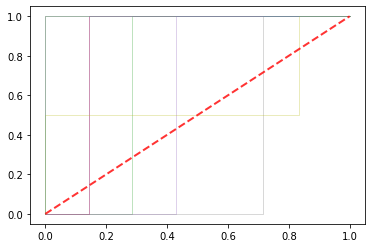

In [17]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
X = pdds_nfl_matrix.reshape(-1, 1)
y = pdds_label_list

classifier = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=None)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for train, test in cv.split(X, y):
    train_X = X[train]
    train_y = y[train]
    test_X = X[test]
    test_y = y[test]
    
    # Compute ROC curve and area the curve
    probas_ = classifier.fit(train_X, train_y).predict_proba(test_X)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)


